<a href="https://colab.research.google.com/github/Raihanbujeee/PCVK_Ganjil_2026/blob/main/modul3.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

 Mengubah tingkat kecerahan citra 
----------------------------------
Masukkan nilai kecerahan: 20


/tmp/ipykernel_3646/4090591448.py:23: RuntimeWarning: overflow encountered in scalar add
  brightness_image[y,x,c] = np.clip(original[y,x,c] + brightness, 0, 255)


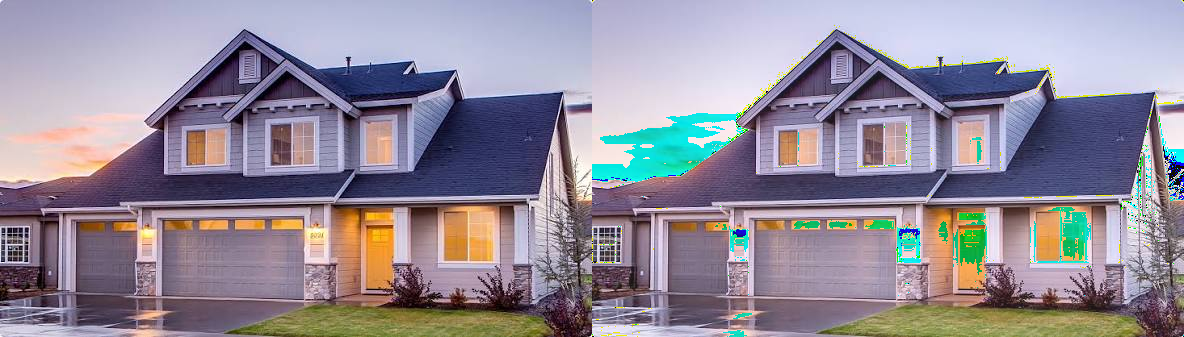

In [2]:
import cv2 as cv
import numpy as np
from google.colab.patches import cv2_imshow



print(' Mengubah tingkat kecerahan citra ')
print('----------------------------------')
try:
    brightness = int(input('Masukkan nilai kecerahan: '))
except ValueError:
    print('Error, not a number')

#sesuaikan dengan file dan folder di drive Anda
original = cv.imread('/content/drive/MyDrive/PCVK/GAMBAR/house.jfif')
brightness_image = np.zeros(original.shape, original.dtype)

#akses per piksel
#np.clip digunakan untuk melakukan truncate pixel (nilai dibatasi antara 0-255)
for y in range(original.shape[0]):
    for x in range(original.shape[1]):
        for c in range(original.shape[2]):
            brightness_image[y,x,c] = np.clip(original[y,x,c] + brightness, 0, 255)

#cara simple tanpa for loop
#brightness_image = cv.convertScaleAbs(original, beta=brightness)

final_frame = cv.hconcat((original, brightness_image))
cv2_imshow(final_frame)

--- TUGAS 1: INVERSE CITRA ---


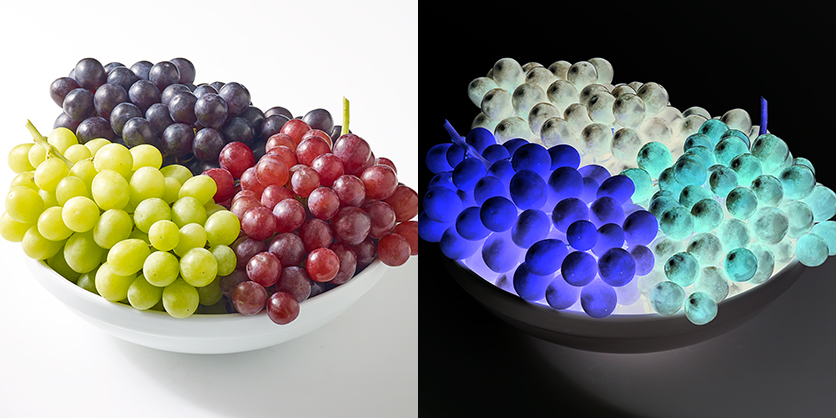

In [3]:
import cv2 as cv
import numpy as np
from google.colab.patches import cv2_imshow

print("--- TUGAS 1: INVERSE CITRA ---")
img_peppers = cv.imread('/content/drive/MyDrive/PCVK/GAMBAR/grape.png')

if img_peppers is None:
    print("Tolong upload gambar")
else:
    inverse_image = 255 - img_peppers
    final_peppers = cv.hconcat((img_peppers, inverse_image))
    cv2_imshow(final_peppers)


--- TUGAS 2: KONTRAST & BRIGHTNESS ---
Mengubah kontras dan tingkat kecerahan citra
---------------------------------------------
Masukkan tingkat kecerahan : 20
Masukkan kontras : 20


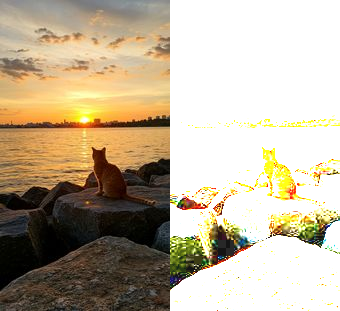

In [4]:
print("\n--- TUGAS 2: KONTRAST & BRIGHTNESS ---")
print('Mengubah kontras dan tingkat kecerahan citra')
print('---------------------------------------------')

try:

    brightness = int(input('Masukkan tingkat kecerahan : '))
    contrast = float(input('Masukkan kontras : '))
except ValueError:
    print('GAGAL!')


img_pemandangan = cv.imread('/content/drive/MyDrive/PCVK/GAMBAR/pemandangan.jpg')

if img_pemandangan is None:
    print("UPLOAD GAMBAR")
else:
    # Proses ubah kontras (alpha) dan brightness (beta)
    contrast_image = cv.convertScaleAbs(img_pemandangan, alpha=contrast, beta=brightness)

    final_pemandangan = cv.hconcat((img_pemandangan, contrast_image))
    cv2_imshow(final_pemandangan)

Mengubah tingkat kecerahan citra dengan Transformasi Log
--------------------------------------------------------
Masukkan nilai kecerahan: 40


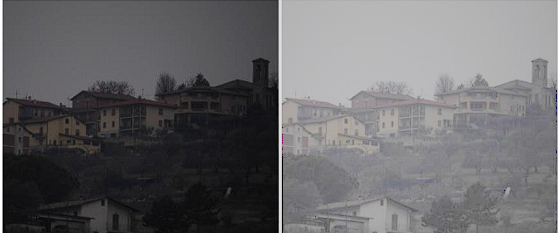

In [5]:
import cv2 as cv
import numpy as np
from google.colab.patches import cv2_imshow

print('Mengubah tingkat kecerahan citra dengan Transformasi Log')
print('--------------------------------------------------------')

try:

    c = int(input('Masukkan nilai kecerahan: '))
except ValueError:
    print('Error, masukin angka yang bener Bro!')


original = cv.imread('/content/drive/MyDrive/PCVK/GAMBAR/gelap.png')

if original is None:
    print("Gambarnya nggak ketemu Bro, cek path lagi!")
else:

    img_float = np.float32(original)

    log_image = c * (np.log1p(img_float))

    log_image = np.clip(log_image, 0, 255)

    log_image = np.array(log_image, dtype=np.uint8)

    final_frame = cv.hconcat((original, log_image))
    cv2_imshow(final_frame)

a. Averaging


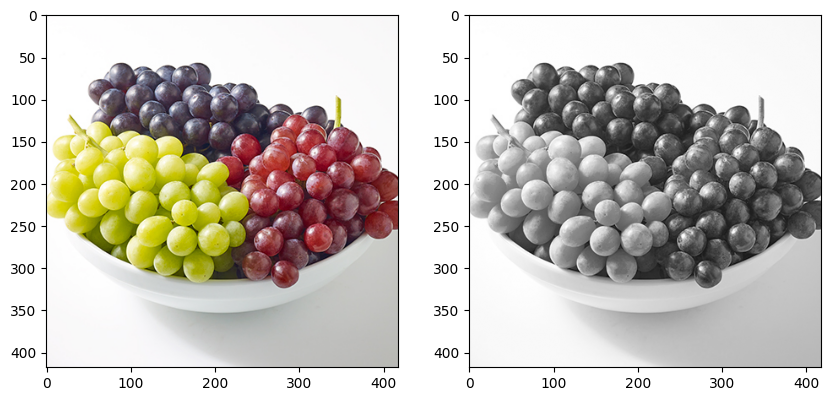

b. Lightness


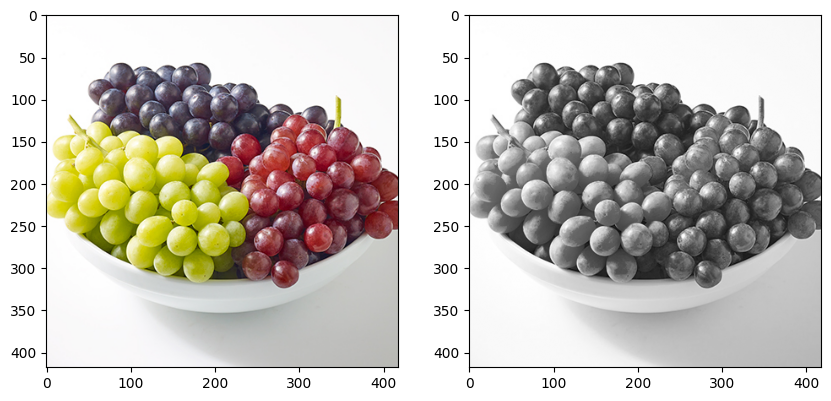

c. Luminance


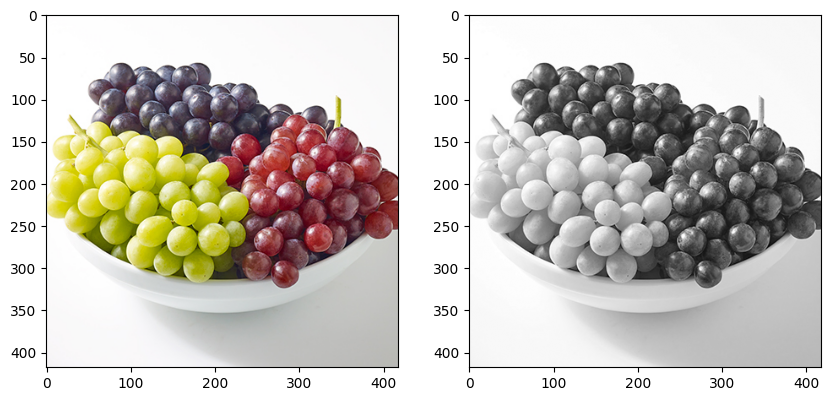

In [6]:
import cv2 as cv
import numpy as np
import matplotlib.pyplot as plt


img_bgr = cv.imread('/content/drive/MyDrive/PCVK/GAMBAR/grape.png')

if img_bgr is None:
    print("Gambar Tidak Ada")
else:

    img_rgb = cv.cvtColor(img_bgr, cv.COLOR_BGR2RGB)


    R = img_rgb[:,:,0].astype(float)
    G = img_rgb[:,:,1].astype(float)
    B = img_rgb[:,:,2].astype(float)


    avg_gray = np.uint8((R + G + B) / 3)

    max_rgb = np.maximum(np.maximum(R, G), B)
    min_rgb = np.minimum(np.minimum(R, G), B)
    lightness_gray = np.uint8((max_rgb + min_rgb) / 2)


    luminance_gray = np.uint8((0.299 * R) + (0.587 * G) + (0.114 * B))


    def tampilkan_hasil(judul, gambar_asli, gambar_gray):
        fig, axes = plt.subplots(1, 2, figsize=(10, 5))


        axes[0].imshow(gambar_asli)


        axes[1].imshow(gambar_gray, cmap='gray')


        plt.suptitle(judul, fontsize=14, x=0.1, y=1.0)
        plt.show()

    print("a. Averaging")
    tampilkan_hasil("", img_rgb, avg_gray)

    print("b. Lightness")
    tampilkan_hasil("", img_rgb, lightness_gray)

    print("c. Luminance")
    tampilkan_hasil("", img_rgb, luminance_gray)

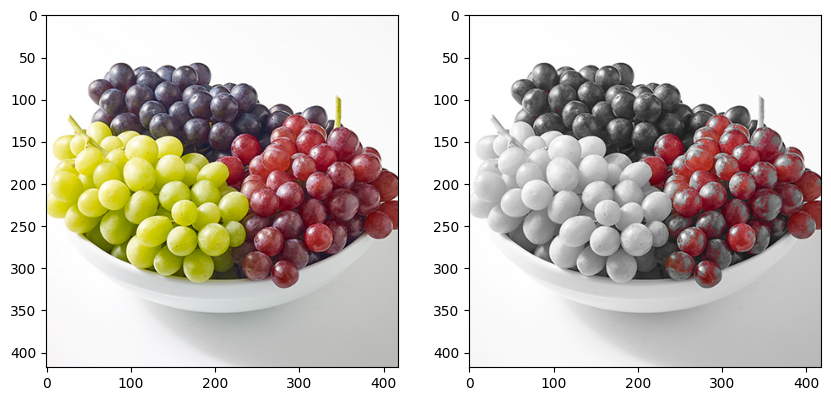

In [7]:
import cv2 as cv
import numpy as np
import matplotlib.pyplot as plt


img_bgr = cv.imread('/content/drive/MyDrive/PCVK/GAMBAR/grape.png')

if img_bgr is None:
    print("Gambar Tidak Ada")
else:

    img_rgb = cv.cvtColor(img_bgr, cv.COLOR_BGR2RGB)


    img_hsv = cv.cvtColor(img_bgr, cv.COLOR_BGR2HSV)


    lower_red1 = np.array([0, 120, 70])
    upper_red1 = np.array([10, 255, 255])
    mask1 = cv.inRange(img_hsv, lower_red1, upper_red1)

    lower_red2 = np.array([170, 120, 70])
    upper_red2 = np.array([180, 255, 255])
    mask2 = cv.inRange(img_hsv, lower_red2, upper_red2)


    mask_red = mask1 + mask2


    mask_not_red = cv.bitwise_not(mask_red)

    gray = cv.cvtColor(img_bgr, cv.COLOR_BGR2GRAY)

    gray_3_channel = cv.cvtColor(gray, cv.COLOR_GRAY2RGB)


    red_part = cv.bitwise_and(img_rgb, img_rgb, mask=mask_red)

    gray_part = cv.bitwise_and(gray_3_channel, gray_3_channel, mask=mask_not_red)


    final_image = cv.add(red_part, gray_part)

    fig, axes = plt.subplots(1, 2, figsize=(10, 5))

    axes[0].imshow(img_rgb)

    axes[1].imshow(final_image)

    plt.show()

 Gamma Correction pada citra 
----------------------------------
Masukkan nilai Gamma: 2


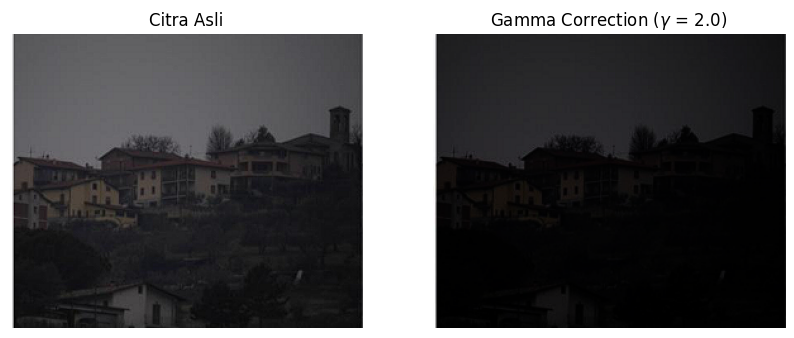

In [9]:
import cv2 as cv
import numpy as np
import matplotlib.pyplot as plt

print(' Gamma Correction pada citra ')
print('----------------------------------')
try:

    gamma = float(input('Masukkan nilai Gamma: '))
except ValueError:
    print('Error, not a number')


img_bgr = cv.imread('/content/drive/MyDrive/PCVK/GAMBAR/gelap.png')

if img_bgr is None:
    print("Gambarnya nggak ketemu Bro, cek path lagi!")
else:

    img_rgb = cv.cvtColor(img_bgr, cv.COLOR_BGR2RGB)

    # --- PROSES GAMMA CORRECTION ---
    # Rumus: (Piksel / 255) ^ gamma * 255
    # 1. Normalisasi piksel jadi skala 0.0 - 1.0
    img_float = img_rgb / 255.0

    # 2. Terapkan rumus gamma
    gamma_corrected = np.power(img_float, gamma)

    # 3. Balikin lagi skalanya ke 0 - 255 dan format jadi integer
    gamma_corrected = np.uint8(gamma_corrected * 255)

    # --- TAMPILKAN HASIL ---
    fig, axes = plt.subplots(1, 2, figsize=(10, 5))

    # Gambar Asli
    axes[0].imshow(img_rgb)
    axes[0].set_title('Citra Asli')
    axes[0].axis('off')

    # Gambar Hasil Gamma
    axes[1].imshow(gamma_corrected)
    axes[1].set_title(rf'Gamma Correction ($\gamma$ = {gamma})')
    axes[1].axis('off')

    plt.show()

Masukkan bit depth tujuan (1-8): 4
Bit depth awal   : 8 bit
Bit depth tujuan : 4 bit
Jumlah level     : 16


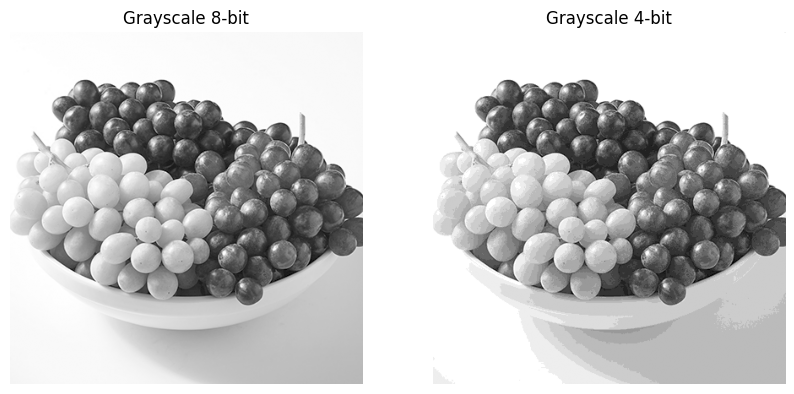

In [10]:
import cv2 as cv
import numpy as np
import matplotlib.pyplot as plt

try:
    # Meminta input dari user
    bit_depth = int(input('Masukkan bit depth tujuan (1-8): '))
except ValueError:
    print('Error, masukin angka dong Bro!')
    bit_depth = 8

if bit_depth < 1 or bit_depth > 8:
    print("Woi, bit depth-nya harus antara 1 sampai 8 aja ya!")
else:
    # --- MENAMPILKAN TEKS INFO ---
    num_levels = pow(2, bit_depth)
    print(f"Bit depth awal   : 8 bit")
    print(f"Bit depth tujuan : {bit_depth} bit")
    print(f"Jumlah level     : {num_levels}")


    original = cv.imread('/content/drive/MyDrive/PCVK/GAMBAR/grape.png', cv.IMREAD_GRAYSCALE)

    if original is None:
        print("Gambarnya nggak kebaca! Cek lagi path-nya udah bener belum.")
    else:
        # --- PROSES SIMULASI BIT DEPTH (KUANTISASI) ---
        # 1. Cari jarak antar warna (interval).
        level_step = 255 / (num_levels - 1) if bit_depth < 8 else 1

        # 2. Proses pembulatan piksel ke level terdekat

        depth_image = np.round(original / level_step) * level_step

        # 3. Ubah formatnya balik ke 8-bit integer buat ditampilin di layar
        depth_image = np.uint8(depth_image)

        # --- TAMPILKAN HASILNYA ---
        fig, axes = plt.subplots(1, 2, figsize=(10, 5))

        # Gambar Asli (Kiri)
        axes[0].imshow(original, cmap='gray')
        axes[0].set_title('Grayscale 8-bit')
        axes[0].axis('off')

        # Gambar Hasil (Kanan)
        axes[1].imshow(depth_image, cmap='gray')
        axes[1].set_title(f'Grayscale {bit_depth}-bit')
        axes[1].axis('off')

        plt.show()

--- Eksperimen Average Denoising ---
Berhasil membaca gambar asli dan 1 gambar noise.

Jumlah Citra:   1 | Nilai PSNR: 10.05 dB
Jumlah Citra:   1 | Nilai PSNR: 10.05 dB
Jumlah Citra:   1 | Nilai PSNR: 10.05 dB
Jumlah Citra:   1 | Nilai PSNR: 10.05 dB
Jumlah Citra:   1 | Nilai PSNR: 10.05 dB


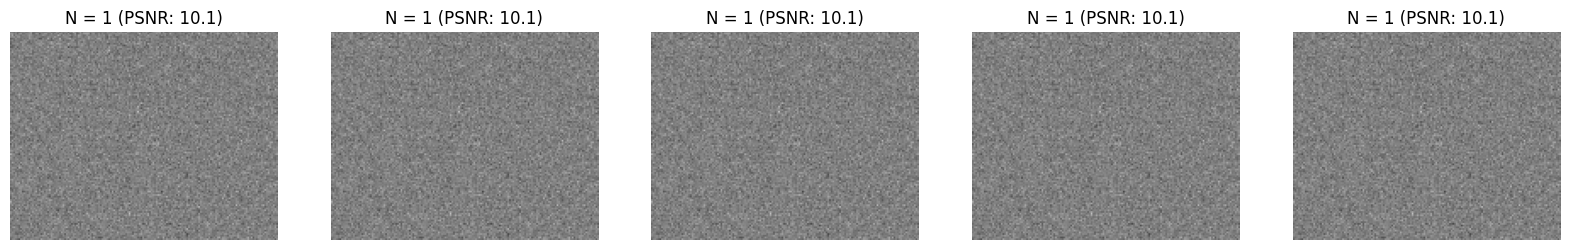

In [12]:
import cv2 as cv
import numpy as np
import glob
import matplotlib.pyplot as plt

print('--- Eksperimen Average Denoising ---')

path_asli = '/content/drive/MyDrive/PCVK/GAMBAR/galaxy.png'
path_noise = '/content/drive/MyDrive/PCVK/GAMBAR/noises/*.jfif'

# 1. Baca citra asli buat pembanding PSNR
original = cv.imread(path_asli)

# 2. Baca 100 citra ber-noise pakai glob
cv_img = []
for img in glob.glob(path_noise):
    n = cv.imread(img)
    if n is not None:
        cv_img.append(n)

if original is None or len(cv_img) == 0:
    print("Gambar tidak ada")
else:
    print(f"Berhasil membaca gambar asli dan {len(cv_img)} gambar noise.\n")

    # Skenario jumlah citra yang mau di-average
    skenario_jumlah = [10, 20, 40, 80, 100]

    fig, axes = plt.subplots(1, 5, figsize=(20, 4))

    for idx, N in enumerate(skenario_jumlah):

        N_actual = N if N <= len(cv_img) else len(cv_img)
        images_to_average = cv_img[:N_actual]

        avg_img = np.zeros(original.shape, np.float32)


        for img in images_to_average:

            img_resized = cv.resize(img, (original.shape[1], original.shape[0]))

            avg_img += img_resized

        # Bagi dengan N_actual untuk cari rata-ratanya
        avg_img /= N_actual

        # Balikin lagi ke format gambar standar (uint8)
        avg_img = np.uint8(avg_img)

        # Hitung PSNR antara gambar asli vs gambar hasil rata-rata
        psnr_value = cv.PSNR(original, avg_img)

        # Print hasil buat lu catat di tabel
        print(f"Jumlah Citra: {N_actual:3} | Nilai PSNR: {psnr_value:.2f} dB")

        # Tampilkan di plot
        axes[idx].imshow(cv.cvtColor(avg_img, cv.COLOR_BGR2RGB))
        axes[idx].set_title(f'N = {N_actual} (PSNR: {psnr_value:.1f})')
        axes[idx].axis('off')

    plt.show()

1. Apakah peningkatan jumlah citra selalu memberikan peningkatan PSNR yang signifikan?
Tidak. Meskipun peningkatan jumlah citra yang dirata-rata selalu menghasilkan peningkatan nilai PSNR, lonjakan peningkatannya tidak selalu signifikan. Peningkatan tersebut bersifat logaritmik, di mana perbaikan kualitas di awal sangat besar, namun perlahan melandai seiring dengan bertambahnya jumlah citra.

2. Pada jumlah citra berapa peningkatan mulai tidak terlalu signifikan?
Peningkatan nilai PSNR mulai tidak terlalu signifikan setelah melewati jumlah 20 hingga 40 citra. Lonjakan kualitas visual dan angka metrik dari 10 ke 20 citra jauh lebih tinggi dibandingkan dengan penambahan dari 80 ke 100 citra.

3. Apa kesimpulan yang Anda peroleh dari percobaan ini?
Berdasarkan percobaan yang telah dilakukan, dapat disimpulkan bahwa metode average denoising sangat efektif untuk mengurangi random noise (seperti Gaussian noise) pada citra statis tanpa merusak detail asli gambar. Semakin banyak citra yang dirata-ratakan, citra yang dihasilkan akan semakin bersih dan nilai PSNR akan semakin tinggi. Namun, terdapat titik jenuh (diminishing returns) pada proses ini, di mana penambahan jumlah citra yang terlalu banyak tidak lagi memberikan perbaikan kualitas visual yang sepadan dengan beban komputasi yang dibutuhkan.




--- Eksperimen Image Masking (Bitwise) ---


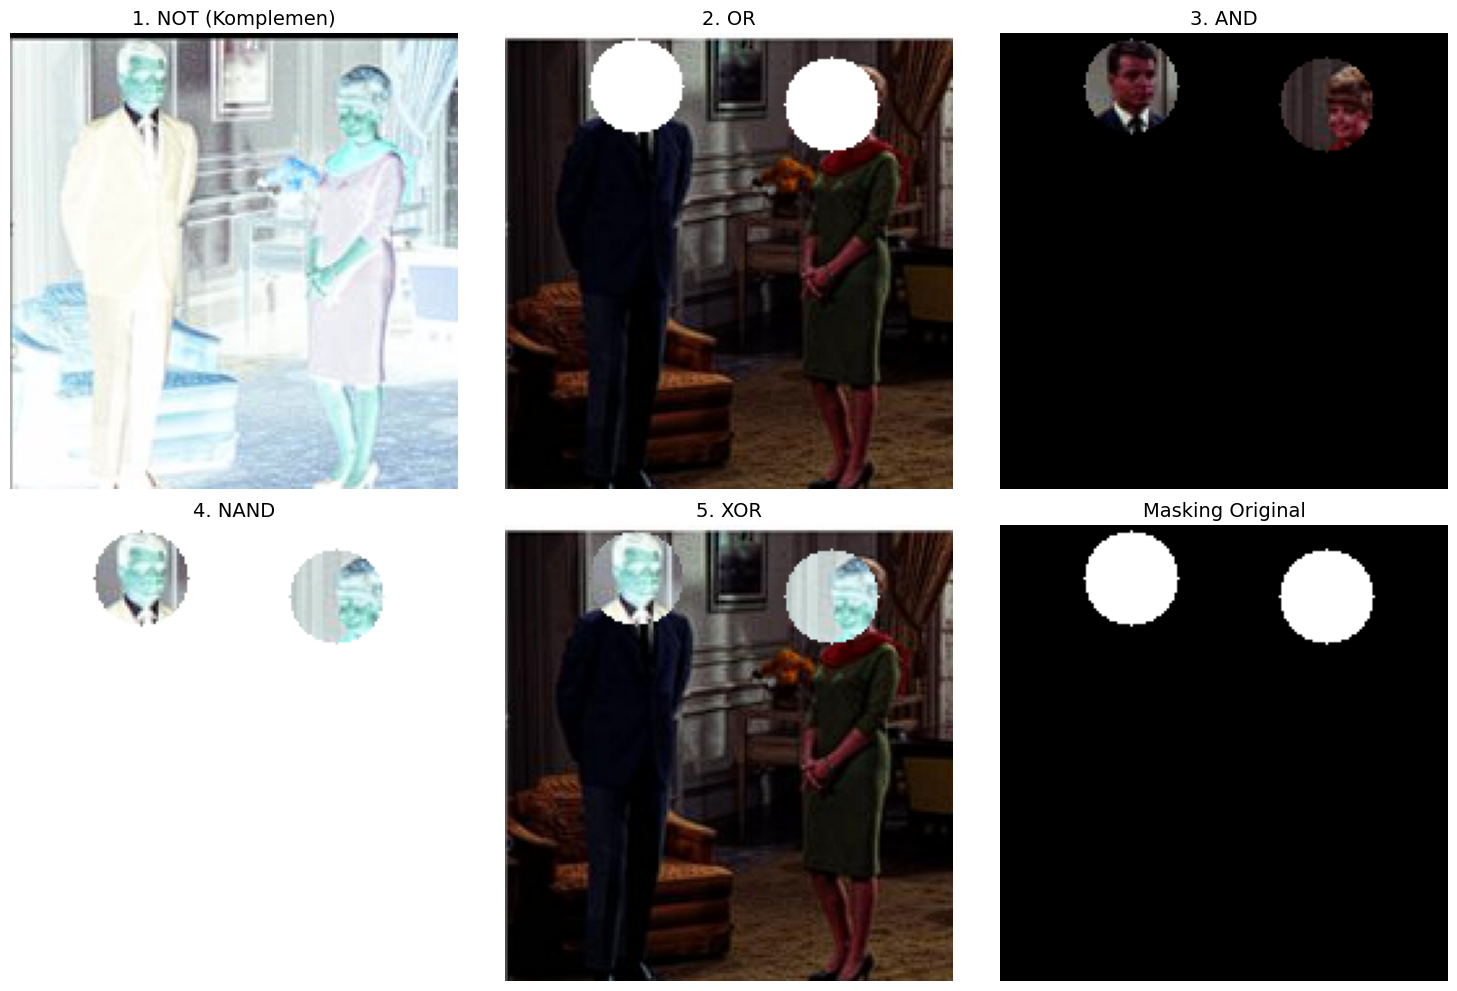

In [18]:
import cv2 as cv
import numpy as np
import matplotlib.pyplot as plt

print('--- Eksperimen Image Masking (Bitwise) ---')

# Path udah sesuai sama punya lu nih
path_gambar = '/content/drive/MyDrive/PCVK/GAMBAR/couple.png'
img_bgr = cv.imread(path_gambar)

if img_bgr is None:
    print("Woi, gambarnya nggak kebaca! Cek lagi path-nya bener apa kagak.")
else:

    img_rgb = cv.cvtColor(img_bgr, cv.COLOR_BGR2RGB)

    # --- BIKIN MASKING ---
    mask = np.zeros(img_rgb.shape[:2], dtype="uint8")



    cv.circle(mask, (50, 20), 18, 255, -1)


    cv.circle(mask, (125, 27), 18, 255, -1)

    mask_3ch = cv.cvtColor(mask, cv.COLOR_GRAY2RGB)

    # --- OPERASI BITWISE ---
    # 1. NOT (Membalik warna citra asli secara keseluruhan)
    hasil_not = cv.bitwise_not(img_rgb)

    # 2. OR (Gambar asli + Mask)
    hasil_or = cv.bitwise_or(img_rgb, mask_3ch)

    # 3. AND
    hasil_and = cv.bitwise_and(img_rgb, mask_3ch)

    # 4. NAND (NOT dari hasil AND)
    hasil_nand = cv.bitwise_not(hasil_and)

    # 5. XOR (Eksklusif OR)
    hasil_xor = cv.bitwise_xor(img_rgb, mask_3ch)

    fig, axes = plt.subplots(2, 3, figsize=(15, 10))
    axes = axes.ravel()

    # Kumpulan judul dan gambar
    titles = ['1. NOT (Komplemen)', '2. OR', '3. AND', '4. NAND', '5. XOR', 'Masking Original']
    images = [hasil_not, hasil_or, hasil_and, hasil_nand, hasil_xor, mask_3ch]

    for i in range(6):
        axes[i].imshow(images[i])
        axes[i].set_title(titles[i], fontsize=14)
        axes[i].axis('off')

    plt.tight_layout()
    plt.show()

Operator NOT (Komplemen): Menghasilkan citra negatif (klise) secara keseluruhan karena operator ini membalikkan seluruh nilai piksel dari citra masukan tanpa dipengaruhi oleh bentuk masking, di mana nilai minimum (0) menjadi maksimum (255) dan sebaliknya.

Operator OR: Menghasilkan citra asli pada area latar belakang yang tertutup mask hitam (0), namun menampilkan warna putih pekat pada area yang sesuai dengan mask putih (255) karena sifat gerbang logika OR yang selalu bernilai maksimal jika salah satu masukannya bernilai maksimal.

Operator AND: Berfungsi untuk melakukan seleksi atau pemotongan (cropping) objek. Area piksel citra asli yang beririsan dengan mask putih (255) akan dipertahankan nilainya, sedangkan area di luar lingkaran mask diubah menjadi hitam pekat (0).

Operator NAND: Merupakan kebalikan dari hasil operasi AND. Area latar belakang yang tadinya bernilai hitam berubah menjadi putih pekat, sementara area wajah di dalam lingkaran mask mengalami pembalikan warna menjadi bentuk negatif atau klise.

Operator XOR: Menghasilkan citra di mana area yang tertutup mask putih (255) mengalami inversi warna menjadi negatif/klise, sedangkan area di luar mask (latar belakang hitam) tetap mempertahankan warna dan detail dari citra aslinya tanpa perubahan.

1. Pilihan Metode yang Digunakan
Metode yang dipilih: Gamma Correction (dengan nilai $\gamma = 0.5$).

2. Alasan Penggunaan Metode

Foto malam hari biasanya mengalami underexposure (kekurangan cahaya), di mana area gelap menutupi detail penting pada citra.Gamma Correction sangat ideal karena menggunakan fungsi non-linear (pangkat) yang mampu mendongkrak atau mencerahkan area gelap secara signifikan, tanpa membuat bagian yang sudah terang menjadi over-exposure (silau atau putih total).Berbeda dengan Linear Brightness yang hanya menambahkan nilai konstan ke seluruh piksel (sehingga area terang bisa rusak menjadi putih mentah), Gamma Correction menjaga transisi gradasi warna tetap natural.

3. Risiko Penggunaan Metode
Munculnya Noise (Bintik-bintik): Karena proses pencerahan juga memperkuat sinyal gelap, noise atau bintik digital yang tadinya tidak terlihat di area gelap akan ikut terangkat dan menjadi lebih jelas (tampak berbintik).Kehilangan Kontras Lokal: Jika nilai gamma diatur terlalu ekstrem, gambar dapat kehilangan kedalaman kontrasnya, sehingga tampak sedikit kabur atau pudar (washed out).

<>:30: SyntaxWarning: invalid escape sequence '\g'
<>:30: SyntaxWarning: invalid escape sequence '\g'
/tmp/ipykernel_3646/954063182.py:30: SyntaxWarning: invalid escape sequence '\g'
  axes[1].set_title(f'Hasil Gamma Correction ($\gamma$ = {gamma})')


--- Studi Kasus: Koreksi Foto Malam Hari ---


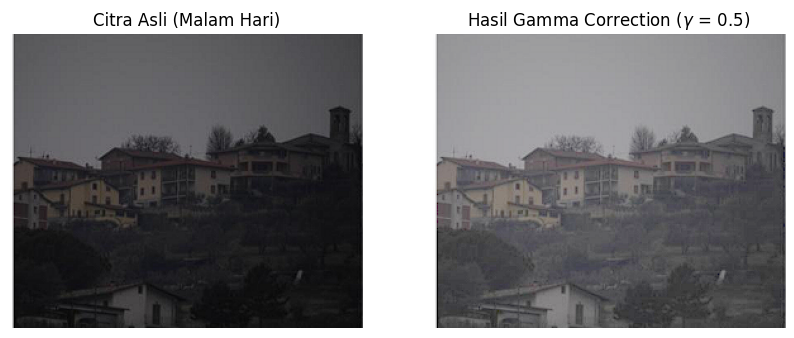

In [19]:
import cv2 as cv
import numpy as np
import matplotlib.pyplot as plt

print('--- Studi Kasus: Koreksi Foto Malam Hari ---')

# INGAT: Ganti path dengan foto malam hari lu di Google Drive!
path_malam = '/content/drive/MyDrive/PCVK/GAMBAR/gelap.png'
img_bgr = cv.imread(path_malam)

if img_bgr is None:
    print("Woi, gambarnya nggak kebaca! Cek lagi path-nya.")
else:
    img_rgb = cv.cvtColor(img_bgr, cv.COLOR_BGR2RGB)

    # Menggunakan Gamma Correction dengan gamma = 0.5 (untuk mencerahkan)
    gamma = 0.5
    img_float = img_rgb / 255.0
    gamma_corrected = np.power(img_float, gamma)
    gamma_corrected = np.uint8(gamma_corrected * 255)

    # Tampilkan hasil perbandingan
    fig, axes = plt.subplots(1, 2, figsize=(10, 5))

    axes[0].imshow(img_rgb)
    axes[0].set_title('Citra Asli (Malam Hari)')
    axes[0].axis('off')

    axes[1].imshow(gamma_corrected)
    axes[1].set_title(f'Hasil Gamma Correction ($\gamma$ = {gamma})')
    axes[1].axis('off')

    plt.show()

1. Metode yang Dipilih

Kombinasi Contrast Adjustment (peregangan kontras) dan Gamma Correction $\gamma = 0.6$ (pencerahan non-linear).

2. Alasan Pemilihan

Citra crayfish.jpg memiliki masalah utama berupa kontras yang sangat rendah serta kondisi pencahayaan air yang keruh, membuat objek udang hampir menyatu dengan warna dasar lumpur.

Contrast Adjustment dipilih untuk merentangkan rentang intensitas piksel agar batas antara objek udang dan latar belakang menjadi jauh lebih tajam.Gamma Correction $(\gamma = 0.6)$ ditambahkan untuk mengangkat detail tersembunyi di area yang gelap tanpa membuat bagian yang terang menjadi silau.

3. Penentuan Parameter Terbaik

Parameter Kontras ($\alpha = 1.5$ hingga $2.0$): Digunakan untuk memperkuat perbedaan warna objek.

Parameter Kecerahan/Beta ($\beta = 20$): Memberikan tambahan cahaya tipis.

Parameter Gamma ($\gamma = 0.6$): Angka di bawah 1 ini dipilih secara optimal agar udang yang semula samar di dalam air keruh menjadi tampak jelas dan terang.

--- Studi Kasus: Enhancing Crayfish Image ---


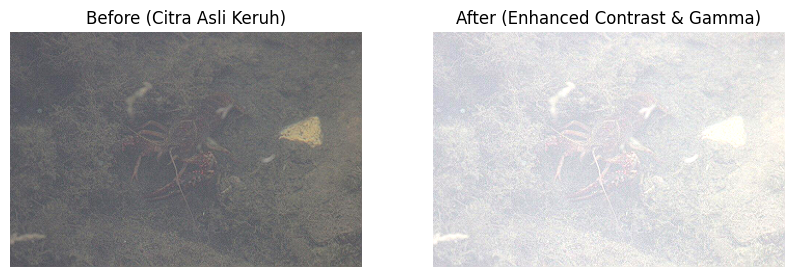

In [20]:
import cv2 as cv
import numpy as np
import matplotlib.pyplot as plt

print('--- Studi Kasus: Enhancing Crayfish Image ---')

path_crayfish = '/content/drive/MyDrive/PCVK/GAMBAR/crayfish.png'
img_bgr = cv.imread(path_crayfish)

if img_bgr is None:
    print("Woi, gambarnya nggak kebaca! Cek lagi path-nya.")
else:
    img_rgb = cv.cvtColor(img_bgr, cv.COLOR_BGR2RGB)

    # 1. Terapkan Contrast Adjustment (alpha=1.8, beta=20)
    alpha = 1.8
    beta = 20
    adjusted = cv.convertScaleAbs(img_rgb, alpha=alpha, beta=beta)

    # 2. Terapkan Gamma Correction (gamma = 0.6) untuk memperjelas detail
    gamma = 0.6
    img_float = adjusted / 255.0
    final_enhanced = np.power(img_float, gamma)
    final_enhanced = np.uint8(final_enhanced * 255)

    # --- Tampilkan Before-After ---
    fig, axes = plt.subplots(1, 2, figsize=(10, 5))

    axes[0].imshow(img_rgb)
    axes[0].set_title('Before (Citra Asli Keruh)')
    axes[0].axis('off')

    axes[1].imshow(final_enhanced)
    axes[1].set_title('After (Enhanced Contrast & Gamma)')
    axes[1].axis('off')

    plt.show()